<a href="https://colab.research.google.com/github/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Cyb3rVigil/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

### Decision rule

The queue answers: **Which pseudonymized pages should a human investigate first, what type of review is appropriate, and why?**

The ranking is deliberately separated into two layers:

- **Validated model signal:** Logistic Regression decline-proxy score, retained only for audit and failure analysis.
- **Operational review priority:** a transparent cost/value score based on historical demand, low CTR, visible position opportunity, position instability and estimated review time.

The model score is excluded from the operational priority calculation because the grouped held-out Top-20 result did not outperform the period base rate.

### Ranked dispositions

The queue orders work in this sequence:

1. `REVIEW` — a visible, actionable pattern deserves human content/SEO review.
2. `INVESTIGATE` — technical, measurement or query causes must be checked before editing.
3. `EXPERIMENTAL_TRIAGE` — the model flagged the page, but transparent actionability evidence is weak.
4. `MONITOR` — the page has value, but current evidence does not justify a change.
5. `DEFER` — preserve limited review capacity until value or evidence increases.

### Reason codes

- `R01_HIGH_DEMAND`: high historical impressions/day; a value signal, not proof of decline.
- `R02_LOW_CTR`: low historical CTR; prompts intent/snippet review, not automatic rewriting.
- `R03_POSITION_4_TO_20`: visible position opportunity.
- `R04_POSITION_VOLATILE`: unstable historical position; investigate technical/query causes.
- `R05_WEAK_POSITION`: average position worse than 20; may require a deeper relevance/authority review.
- `R06_EXPERIMENTAL_MODEL_TOP20`: audit-only model flag.
- `R07_REFRESH_METADATA_REQUIRED`: age, last update and editorial history must be checked manually.
- `R08_LOW_VALUE_DEFER`: no current high-value/actionable pattern.

### Archetype-to-action policy

The notebook creates seven archetypes: high-value SERP gap, volatile visibility, deep relevance gap, high-value monitor, light SERP opportunity, model-only experimental and low-value watchlist. Every archetype maps to a bounded human task, reviewer role, estimated cost and refresh gate.

### Decay/refresh insight

The research paper reported a large observed freshness association for mature pages, but refreshed pages were not randomly assigned. Selection bias is plausible: editors may choose high-value pages for refresh. My current five model features also do not include page age, last meaningful update or editorial history.

Therefore, **freshness is a human-review hypothesis, not an automated action**. A page can enter refresh consideration only after a reviewer verifies staleness, intent drift, factual ageing, technical health and continued business relevance.

In [1]:
%pip -q install duckdb huggingface_hub pandas numpy scikit-learn matplotlib

import json
import os
import subprocess
import sys
from datetime import datetime, timezone
from getpass import getpass
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import Markdown, display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 0. Reproducible environment and repository path
# ---------------------------------------------------------

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 220)

REPO_NAME = "flyrank-ml-internship"
REPO_URL = "https://github.com/Cyb3rVigil/flyrank-ml-internship.git"

def resolve_repo_root():
    candidates = [
        Path.cwd(),
        Path.cwd() / REPO_NAME,
        Path("/content") / REPO_NAME,
    ]

    for candidate in candidates:
        if (
            (candidate / "skills" / "README.md").exists()
            and (candidate / "work" / "notebooks").exists()
        ):
            return candidate.resolve()

    clone_target = Path("/content") / REPO_NAME

    if Path("/content").exists():
        if not clone_target.exists():
            subprocess.run(
                [
                    "git",
                    "clone",
                    "--depth",
                    "1",
                    REPO_URL,
                    str(clone_target),
                ],
                check=True,
            )

        if (
            (clone_target / "skills" / "README.md").exists()
            and (clone_target / "work" / "notebooks").exists()
        ):
            return clone_target.resolve()

    raise FileNotFoundError(
        "Repository root was not found. Run this notebook from the "
        "flyrank-ml-internship repository or open it in Google Colab "
        "with internet access."
    )

REPO_ROOT = resolve_repo_root()
os.chdir(REPO_ROOT)

OUTPUT_DIR = REPO_ROOT / "work" / "outputs"
FIGURE_DIR = REPO_ROOT / "work" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)

# ---------------------------------------------------------
# 1. Secure Hugging Face access
# ---------------------------------------------------------

HF_TOKEN = os.environ.get("HF_TOKEN", "").strip()

try:
    from google.colab import userdata

    HF_TOKEN = HF_TOKEN or (userdata.get("HF_TOKEN") or "").strip()
except Exception:
    pass

if not HF_TOKEN:
    HF_TOKEN = getpass(
        "Enter your Hugging Face READ token. Input is hidden and is "
        "not saved in the notebook: "
    ).strip()

if not HF_TOKEN:
    raise RuntimeError(
        "A Hugging Face READ token is required for the gated "
        "FlyRank/internship-warehouse dataset. Request access to the "
        "dataset and provide the token through Colab Secrets or the "
        "hidden prompt. Never paste the token into a code cell."
    )

safe_token = HF_TOKEN.replace("'", "''")

con = duckdb.connect()
con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{safe_token}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

MARCH_DAILY = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/"
    f"month=2026-03/*.parquet'"
    f")"
)

# ---------------------------------------------------------
# 2. Rebuild the exact Week-5 / Week-6 modeling frame
# ---------------------------------------------------------

feature_sql = f"""
WITH aggregated AS (
    SELECT
        client_hash_id,
        content_hash_id,

        COUNT(DISTINCT report_date) FILTER (
            WHERE report_date < DATE '2026-03-22'
        ) AS hist_days,

        COUNT(DISTINCT report_date) FILTER (
            WHERE report_date >= DATE '2026-03-22'
        ) AS outcome_days,

        SUM(gsc_impressions) FILTER (
            WHERE report_date < DATE '2026-03-22'
        ) AS hist_impressions,

        SUM(gsc_clicks) FILTER (
            WHERE report_date < DATE '2026-03-22'
        ) AS hist_clicks,

        SUM(gsc_impressions) FILTER (
            WHERE report_date >= DATE '2026-03-22'
        ) AS outcome_impressions,

        (
            SUM(
                gsc_avg_position * gsc_impressions
            ) FILTER (
                WHERE report_date < DATE '2026-03-22'
            )
            /
            NULLIF(
                SUM(gsc_impressions) FILTER (
                    WHERE report_date < DATE '2026-03-22'
                ),
                0
            )
        ) AS hist_avg_position,

        STDDEV_SAMP(gsc_avg_position) FILTER (
            WHERE report_date < DATE '2026-03-22'
              AND gsc_impressions > 0
        ) AS hist_position_sd

    FROM {MARCH_DAILY}

    WHERE ga4_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id
),

framed AS (
    SELECT
        *,

        1.0 * hist_impressions
            / NULLIF(hist_days, 0)
            AS hist_imp_per_day,

        1.0 * hist_clicks
            / NULLIF(hist_days, 0)
            AS hist_click_per_day,

        1.0 * hist_clicks
            / NULLIF(hist_impressions, 0)
            AS hist_ctr,

        1.0 * outcome_impressions
            / NULLIF(outcome_days, 0)
            AS outcome_imp_per_day

    FROM aggregated

    WHERE hist_days >= 14
      AND outcome_days >= 7
      AND hist_impressions >= 50
)

SELECT
    client_hash_id,
    content_hash_id,
    hist_days,
    outcome_days,
    hist_imp_per_day,
    hist_click_per_day,
    hist_ctr,
    hist_avg_position,
    hist_position_sd,

    CAST(
        outcome_imp_per_day
        < 0.8 * hist_imp_per_day
        AS INTEGER
    ) AS is_declining_proxy

FROM framed
"""

raw_frame = con.sql(feature_sql).df()

FEATURES = [
    "hist_imp_per_day",
    "hist_click_per_day",
    "hist_ctr",
    "hist_avg_position",
    "hist_position_sd",
]

LABEL = "is_declining_proxy"
GROUP = "client_hash_id"
CONTENT_ID = "content_hash_id"

model_frame = (
    raw_frame
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=FEATURES + [LABEL, GROUP, CONTENT_ID])
    .copy()
)

model_frame[LABEL] = model_frame[LABEL].astype(int)

assert not model_frame.empty
assert model_frame[LABEL].nunique() == 2
assert model_frame.duplicated([GROUP, CONTENT_ID]).sum() == 0
assert len(FEATURES) == 5

# ---------------------------------------------------------
# 3. Honest client-grouped holdout
# ---------------------------------------------------------

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=SEED,
)

train_idx, test_idx = next(
    splitter.split(
        model_frame[FEATURES],
        model_frame[LABEL],
        groups=model_frame[GROUP],
    )
)

train_frame = (
    model_frame
    .iloc[train_idx]
    .reset_index(drop=True)
)

test_frame = (
    model_frame
    .iloc[test_idx]
    .reset_index(drop=True)
)

train_clients = set(train_frame[GROUP])
test_clients = set(test_frame[GROUP])

assert train_clients.isdisjoint(test_clients)
assert train_frame[LABEL].nunique() == 2
assert test_frame[LABEL].nunique() == 2
assert len(train_frame) + len(test_frame) == len(model_frame)

# ---------------------------------------------------------
# 4. Transparent Week-4 actionability signals
#    Thresholds are fitted on training clients only.
# ---------------------------------------------------------

baseline_thresholds = {
    "high_demand_q75": float(
        train_frame["hist_imp_per_day"].quantile(0.75)
    ),
    "low_ctr_q25": float(
        train_frame["hist_ctr"].quantile(0.25)
    ),
    "high_volatility_q75": float(
        train_frame["hist_position_sd"].quantile(0.75)
    ),
}

def add_transparent_signals(frame):
    scored = frame.copy()

    scored["flag_high_demand"] = (
        scored["hist_imp_per_day"]
        >= baseline_thresholds["high_demand_q75"]
    ).astype(int)

    scored["flag_position_opportunity"] = (
        scored["hist_avg_position"].between(
            4.0,
            20.0,
            inclusive="both",
        )
    ).astype(int)

    scored["flag_low_ctr"] = (
        scored["hist_ctr"]
        <= baseline_thresholds["low_ctr_q25"]
    ).astype(int)

    scored["flag_position_instability"] = (
        scored["hist_position_sd"]
        >= baseline_thresholds["high_volatility_q75"]
    ).astype(int)

    scored["flag_weak_position"] = (
        scored["hist_avg_position"] > 20.0
    ).astype(int)

    scored["actionability_score"] = (
        4 * scored["flag_high_demand"]
        + 3 * scored["flag_position_opportunity"]
        + 2 * scored["flag_low_ctr"]
        + 1 * scored["flag_position_instability"]
    )

    scored["score_week4_rule"] = scored["actionability_score"]

    return scored

evaluation = add_transparent_signals(test_frame)

# ---------------------------------------------------------
# 5. Refit the validated Logistic Regression design
#    The model score is retained for audit only.
# ---------------------------------------------------------

logistic_model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
])

logistic_model.fit(
    train_frame[FEATURES],
    train_frame[LABEL],
)

evaluation["model_score_audit_only"] = (
    logistic_model.predict_proba(
        evaluation[FEATURES]
    )[:, 1]
)

def ranked_copy(frame, score_column):
    return (
        frame
        .sort_values(
            by=[
                score_column,
                "hist_imp_per_day",
                "hist_click_per_day",
                CONTENT_ID,
            ],
            ascending=[False, False, False, True],
        )
        .reset_index(drop=True)
    )

def precision_at_k(frame, score_column, k):
    ranked = ranked_copy(frame, score_column)
    effective_k = min(k, len(ranked))

    return float(
        ranked
        .head(effective_k)[LABEL]
        .mean()
    )

test_base_rate = float(evaluation[LABEL].mean())

model_p20 = precision_at_k(
    evaluation,
    "model_score_audit_only",
    20,
)

model_p50 = precision_at_k(
    evaluation,
    "model_score_audit_only",
    50,
)

baseline_p20 = precision_at_k(
    evaluation,
    "score_week4_rule",
    20,
)

model_average_precision = float(
    average_precision_score(
        evaluation[LABEL],
        evaluation["model_score_audit_only"],
    )
)

model_roc_auc = float(
    roc_auc_score(
        evaluation[LABEL],
        evaluation["model_score_audit_only"],
    )
)

evaluation["model_rank_audit_only"] = (
    evaluation["model_score_audit_only"]
    .rank(method="first", ascending=False)
    .astype(int)
)

evaluation["flag_experimental_model_top20"] = (
    evaluation["model_rank_audit_only"] <= 20
).astype(int)

validation_summary = pd.DataFrame([{
    "model": "Logistic Regression",
    "eligible_rows": len(model_frame),
    "eligible_clients": model_frame[GROUP].nunique(),
    "train_rows": len(train_frame),
    "train_clients": train_frame[GROUP].nunique(),
    "test_rows": len(test_frame),
    "test_clients": test_frame[GROUP].nunique(),
    "client_overlap": len(
        train_clients.intersection(test_clients)
    ),
    "test_base_rate": test_base_rate,
    "precision_at_20": model_p20,
    "precision_at_50": model_p50,
    "average_precision": model_average_precision,
    "roc_auc": model_roc_auc,
    "baseline_precision_at_20": baseline_p20,
    "production_gate": "BLOCKED",
}])

# ---------------------------------------------------------
# 6. Archetype -> action mapping
# ---------------------------------------------------------

def classify_archetype(row):
    if (
        row["flag_high_demand"] == 1
        and row["flag_position_opportunity"] == 1
        and row["flag_low_ctr"] == 1
    ):
        return "A1_HIGH_VALUE_SERP_GAP"

    if (
        row["flag_high_demand"] == 1
        and row["flag_position_instability"] == 1
    ):
        return "A2_VOLATILE_VISIBILITY"

    if (
        row["flag_high_demand"] == 1
        and row["flag_weak_position"] == 1
    ):
        return "A3_DEEP_RELEVANCE_GAP"

    if row["flag_high_demand"] == 1:
        return "A4_HIGH_VALUE_MONITOR"

    if (
        row["flag_position_opportunity"] == 1
        and row["flag_low_ctr"] == 1
    ):
        return "A5_LIGHT_SERP_OPPORTUNITY"

    if row["flag_experimental_model_top20"] == 1:
        return "A6_MODEL_ONLY_EXPERIMENTAL"

    return "A7_LOW_VALUE_WATCHLIST"

ACTION_MAP = {
    "A1_HIGH_VALUE_SERP_GAP": {
        "recommended_action": (
            "Review search intent, title, meta description and "
            "SERP promise. Preserve strong sections; make only "
            "human-approved edits."
        ),
        "disposition": "REVIEW",
        "reviewer_role": "SEO analyst + content editor",
        "estimated_review_hours": 0.75,
        "refresh_gate": "HUMAN_STALENESS_CHECK_REQUIRED",
        "decay_refresh_note": (
            "Check page age, last meaningful update, intent drift "
            "and competing results before deciding whether a refresh "
            "is justified."
        ),
    },
    "A2_VOLATILE_VISIBILITY": {
        "recommended_action": (
            "Investigate query mix, cannibalization, indexing, "
            "canonical status, template changes and recent technical "
            "events before editing content."
        ),
        "disposition": "INVESTIGATE",
        "reviewer_role": "SEO analyst + technical reviewer",
        "estimated_review_hours": 1.50,
        "refresh_gate": "TECHNICAL_CAUSE_CHECK_FIRST",
        "decay_refresh_note": (
            "Volatility is not proof of content decay. Rule out "
            "measurement and technical causes before considering a "
            "refresh."
        ),
    },
    "A3_DEEP_RELEVANCE_GAP": {
        "recommended_action": (
            "Perform a deep relevance, coverage, internal-link and "
            "authority review. Do not auto-rewrite or expand the page."
        ),
        "disposition": "REVIEW",
        "reviewer_role": "Senior content strategist + SEO analyst",
        "estimated_review_hours": 3.00,
        "refresh_gate": "HUMAN_STALENESS_CHECK_REQUIRED",
        "decay_refresh_note": (
            "A refresh is only one possible intervention. Confirm "
            "staleness, intent change and business relevance first."
        ),
    },
    "A4_HIGH_VALUE_MONITOR": {
        "recommended_action": (
            "Protect working elements and review for emerging risk. "
            "Do not change the page only because it has high value."
        ),
        "disposition": "MONITOR",
        "reviewer_role": "SEO analyst",
        "estimated_review_hours": 0.50,
        "refresh_gate": "DO_NOT_REFRESH_BY_DEFAULT",
        "decay_refresh_note": (
            "High demand alone is not evidence of decay or a reason "
            "to refresh."
        ),
    },
    "A5_LIGHT_SERP_OPPORTUNITY": {
        "recommended_action": (
            "Run a light search-intent and snippet review. Confirm "
            "that the page is strategically important before editing."
        ),
        "disposition": "REVIEW",
        "reviewer_role": "SEO analyst + content editor",
        "estimated_review_hours": 0.75,
        "refresh_gate": "HUMAN_STALENESS_CHECK_REQUIRED",
        "decay_refresh_note": (
            "Check last update date and intent drift. Low CTR alone "
            "does not prove stale content."
        ),
    },
    "A6_MODEL_ONLY_EXPERIMENTAL": {
        "recommended_action": (
            "Analyst triage only. Record why the model flag appears "
            "plausible or implausible; do not make a content change "
            "from this signal alone."
        ),
        "disposition": "EXPERIMENTAL_TRIAGE",
        "reviewer_role": "ML analyst + SEO analyst",
        "estimated_review_hours": 0.50,
        "refresh_gate": "NO_REFRESH_FROM_MODEL_ONLY",
        "decay_refresh_note": (
            "The model did not demonstrate useful Top-20 precision "
            "on unseen clients, so a model-only flag cannot justify "
            "a refresh."
        ),
    },
    "A7_LOW_VALUE_WATCHLIST": {
        "recommended_action": (
            "Defer active work. Monitor until demand, strategic value "
            "or stronger evidence makes review worthwhile."
        ),
        "disposition": "DEFER",
        "reviewer_role": "SEO analyst",
        "estimated_review_hours": 0.25,
        "refresh_gate": "DO_NOT_REFRESH_BY_DEFAULT",
        "decay_refresh_note": (
            "Do not spend refresh capacity without a verified "
            "business or user-value reason."
        ),
    },
}

evaluation["archetype"] = evaluation.apply(
    classify_archetype,
    axis=1,
)

for field in [
    "recommended_action",
    "disposition",
    "reviewer_role",
    "estimated_review_hours",
    "refresh_gate",
    "decay_refresh_note",
]:
    evaluation[field] = evaluation["archetype"].map(
        lambda archetype: ACTION_MAP[archetype][field]
    )

# ---------------------------------------------------------
# 7. Reason codes
# ---------------------------------------------------------

reason_codebook = pd.DataFrame([
    {
        "reason_code": "R01_HIGH_DEMAND",
        "meaning": (
            "Historical impressions per day are at or above the "
            "training-client 75th percentile."
        ),
        "use": "Value signal; not evidence of decline.",
    },
    {
        "reason_code": "R02_LOW_CTR",
        "meaning": (
            "Historical CTR is at or below the training-client "
            "25th percentile."
        ),
        "use": "Prompts intent/snippet review; not an automatic rewrite.",
    },
    {
        "reason_code": "R03_POSITION_4_TO_20",
        "meaning": "Historical average position is between 4 and 20.",
        "use": "Marks a visible but not top-position opportunity.",
    },
    {
        "reason_code": "R04_POSITION_VOLATILE",
        "meaning": (
            "Historical position standard deviation is at or above "
            "the training-client 75th percentile."
        ),
        "use": "Prompts technical/query investigation before editing.",
    },
    {
        "reason_code": "R05_WEAK_POSITION",
        "meaning": "Historical average position is worse than 20.",
        "use": "Prompts a deeper relevance/authority review.",
    },
    {
        "reason_code": "R06_EXPERIMENTAL_MODEL_TOP20",
        "meaning": "The page is in the model's Top-20 held-out ranking.",
        "use": (
            "Audit-only signal because held-out Precision@20 did not "
            "support automated ranking use."
        ),
    },
    {
        "reason_code": "R07_REFRESH_METADATA_REQUIRED",
        "meaning": (
            "Page age, last meaningful update and editorial history "
            "are not model features."
        ),
        "use": "A human must verify decay/staleness before any refresh.",
    },
    {
        "reason_code": "R08_LOW_VALUE_DEFER",
        "meaning": "No current high-value/actionable pattern was observed.",
        "use": "Defer work and preserve limited review capacity.",
    },
])

def build_reason_codes(row):
    codes = []

    if row["flag_high_demand"] == 1:
        codes.append("R01_HIGH_DEMAND")

    if row["flag_low_ctr"] == 1:
        codes.append("R02_LOW_CTR")

    if row["flag_position_opportunity"] == 1:
        codes.append("R03_POSITION_4_TO_20")

    if row["flag_position_instability"] == 1:
        codes.append("R04_POSITION_VOLATILE")

    if row["flag_weak_position"] == 1:
        codes.append("R05_WEAK_POSITION")

    if row["flag_experimental_model_top20"] == 1:
        codes.append("R06_EXPERIMENTAL_MODEL_TOP20")

    if "CHECK" in row["refresh_gate"]:
        codes.append("R07_REFRESH_METADATA_REQUIRED")

    if row["disposition"] == "DEFER":
        codes.append("R08_LOW_VALUE_DEFER")

    if not codes:
        codes.append("R08_LOW_VALUE_DEFER")

    return ";".join(codes)

evaluation["reason_codes"] = evaluation.apply(
    build_reason_codes,
    axis=1,
)

# ---------------------------------------------------------
# 8. Cost/value ranking
#    IMPORTANT: model score is excluded from the priority score.
# ---------------------------------------------------------

evaluation["demand_percentile"] = (
    evaluation["hist_imp_per_day"]
    .rank(method="average", pct=True)
)

evaluation["business_value_score"] = (
    100.0 * evaluation["demand_percentile"]
)

evaluation["value_tier"] = np.select(
    [
        evaluation["demand_percentile"] >= 0.75,
        evaluation["demand_percentile"] >= 0.40,
    ],
    [
        "HIGH",
        "MEDIUM",
    ],
    default="LOW",
)

evaluation["priority_score"] = (
    (
        evaluation["business_value_score"]
        + 10.0 * evaluation["actionability_score"]
    )
    / evaluation["estimated_review_hours"].clip(lower=0.50)
)

disposition_order = {
    "REVIEW": 1,
    "INVESTIGATE": 2,
    "EXPERIMENTAL_TRIAGE": 3,
    "MONITOR": 4,
    "DEFER": 5,
}

evaluation["disposition_order"] = (
    evaluation["disposition"].map(disposition_order)
)

evaluation["human_review_required"] = True
evaluation["automation_allowed"] = False
evaluation["model_signal_use"] = "AUDIT_ONLY"
evaluation["rank_basis"] = (
    "Transparent value + actionability + estimated review cost; "
    "model score excluded"
)

action_queue = (
    evaluation
    .sort_values(
        by=[
            "disposition_order",
            "priority_score",
            "hist_imp_per_day",
            CONTENT_ID,
        ],
        ascending=[True, False, False, True],
    )
    .reset_index(drop=True)
)

action_queue.insert(
    0,
    "queue_rank",
    np.arange(1, len(action_queue) + 1),
)

archetype_playbook = pd.DataFrame([
    {
        "archetype": archetype,
        **details,
    }
    for archetype, details in ACTION_MAP.items()
])

print("VALIDATION SUMMARY")
display(validation_summary.round(4))

print("REASON-CODE DICTIONARY")
display(reason_codebook)

print("ARCHETYPE -> ACTION PLAYBOOK")
display(archetype_playbook)

print("TOP 20 HUMAN-REVIEW QUEUE")
display(
    action_queue[[
        "queue_rank",
        GROUP,
        CONTENT_ID,
        "archetype",
        "disposition",
        "recommended_action",
        "reason_codes",
        "value_tier",
        "priority_score",
        "estimated_review_hours",
        "refresh_gate",
        "model_score_audit_only",
        "model_rank_audit_only",
    ]]
    .head(20)
    .round({
        "priority_score": 2,
        "estimated_review_hours": 2,
        "model_score_audit_only": 4,
    })
)

print(
    "\nDecision policy: this is a human-review queue. "
    "Automation and production deployment are blocked."
)

Repository root: /content/flyrank-ml-internship


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

VALIDATION SUMMARY


,model,eligible_rows,eligible_clients,train_rows,train_clients,test_rows,test_clients,client_overlap,test_base_rate,precision_at_20,precision_at_50,average_precision,roc_auc,baseline_precision_at_20,production_gate
0,Logistic Regression,2348,14,2120,10,228,4,0,0.057,0.0,0.04,0.0461,0.3284,0.0,BLOCKED


REASON-CODE DICTIONARY


...

ARCHETYPE -> ACTION PLAYBOOK


,archetype,recommended_action,disposition,reviewer_role,estimated_review_hours,refresh_gate,decay_refresh_note
0,A1_HIGH_VALUE_SERP_GAP,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",REVIEW,SEO analyst + content editor,0.75,HUMAN_STALENESS_CHECK_REQUIRED,"Check page age, last meaningful update, intent drift and competing results before deciding whether a refresh is justified."
1,A2_VOLATILE_VISIBILITY,"Investigate query mix, cannibalization, indexing, canonical status, template changes and recent technical events before editing content.",INVESTIGATE,SEO analyst + technical reviewer,1.50,TECHNICAL_CAUSE_CHECK_FIRST,Volatility is not proof of content decay. Rule out measurement and technical causes before considering a refresh.
2,A3_DEEP_RELEVANCE_GAP,"Perform a deep relevance, coverage, internal-link and authority review. Do not auto-rewrite or expand the page.",REVIEW,Senior content strategist + SEO analyst,3.00,HUMAN_STALENESS_CHECK_REQUIRED,"A refresh is only one possible intervention. Confirm staleness, intent change and business relevance first."
3,A4_HIGH_VALUE_MONITOR,Protect working elements and review for emerging risk. Do not change the page only because it has high value.,MONITOR,SEO analyst,0.50,DO_NOT_REFRESH_BY_DEFAULT,High demand alone is not evidence of decay or a reason to refresh.
4,A5_LIGHT_SERP_OPPORTUNITY,Run a light search-intent and snippet review. Confirm that the page is strategically important before editing.,REVIEW,SEO analyst + content editor,0.75,HUMAN_STALENESS_CHECK_REQUIRED,Check last update date and intent drift. Low CTR alone does not prove stale content.
5,A6_MODEL_ONLY_EXPERIMENTAL,Analyst triage only. Record why the model flag appears plausible or implausible; do not make a content change from this signal alone.,EXPERIMENTAL_TRIAGE,ML analyst + SEO analyst,0.50,NO_REFRESH_FROM_MODEL_ONLY,"The model did not demonstrate useful Top-20 precision on unseen clients, so a model-only flag cannot justify a refresh."
6,A7_LOW_VALUE_WATCHLIST,"Defer active work. Monitor until demand, strategic value or stronger evidence makes review worthwhile.",DEFER,SEO analyst,0.25,DO_NOT_REFRESH_BY_DEFAULT,Do not spend refresh capacity without a verified business or user-value reason.


TOP 20 HUMAN-REVIEW QUEUE


,queue_rank,client_hash_id,content_hash_id,archetype,disposition,recommended_action,reason_codes,value_tier,priority_score,estimated_review_hours,refresh_gate,model_score_audit_only,model_rank_audit_only
0,1,client_fef1a8f436438636,content_811c0e6db6e2cb7b,A1_HIGH_VALUE_SERP_GAP,REVIEW,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,HIGH,250.99,0.75,HUMAN_STALENESS_CHECK_REQUIRED,0.3328,67
1,2,client_fef1a8f436438636,content_69560b448e635cdc,A1_HIGH_VALUE_SERP_GAP,REVIEW,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,HIGH,249.82,0.75,HUMAN_STALENESS_CHECK_REQUIRED,0.3453,57
2,3,client_fef1a8f436438636,content_0c681b2238bd38b7,A1_HIGH_VALUE_SERP_GAP,REVIEW,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,HIGH,249.24,0.75,HUMAN_STALENESS_CHECK_REQUIRED,0.4481,23
3,4,client_fef1a8f436438636,content_65cd4058b82bdfee,A1_HIGH_VALUE_SERP_GAP,REVIEW,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R06_EXPERIMENTAL_MODEL_TOP20;R07_REFRESH_METADATA_REQUIRED,HIGH,248.07,0.75,HUMAN_STALENESS_CHECK_REQUIRED,0.4812,20
4,5,client_fef1a8f436438636,content_58e36f43789b26ff,A1_HIGH_VALUE_SERP_GAP,REVIEW,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,HIGH,230.53,0.75,HUMAN_STALENESS_CHECK_REQUIRED,0.3215,74
5,6,client_fef1a8f436438636,content_37074680795f74a0,A1_HIGH_VALUE_SERP_GAP,REVIEW,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,HIGH,227.02,0.75,HUMAN_STALENESS_CHECK_REQUIRED,0.4364,25
6,7,client_fef1a8f436438636,content_460903387655a538,A5_LIGHT_SERP_OPPORTUNITY,REVIEW,Run a light search-intent and snippet review. Confirm that the page is strategically important before editing.,R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,HIGH,169.59,0.75,HUMAN_STALENESS_CHECK_REQUIRED,0.4090,32
7,8,client_fef1a8f436438636,content_1e58361008ae490c,A5_LIGHT_SERP_OPPORTUNITY,REVIEW,Run a light search-intent and snippet review. Confirm that the page is strategically important before editing.,R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,HIGH,167.25,0.75,HUMAN_STALENESS_CHECK_REQUIRED,0.3292,70
8,9,client_fef1a8f436438636,content_8a32ab97c7c15874,A5_LIGHT_SERP_OPPORTUNITY,REVIEW,Run a light search-intent and snippet review. Confirm that the page is strategically important before editing.,R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,MEDIUM,165.50,0.75,HUMAN_STALENESS_CHECK_REQUIRED,0.2935,104
9,10,client_fef1a8f436438636,content_aba4a8a6a8a8b2f9,A5_LIGHT_SERP_OPPORTUNITY,REVIEW,Run a light search-intent and snippet review. Confirm that the page is strategically important before editing.,R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,LOW,104.09,0.75,HUMAN_STALENESS_CHECK_REQUIRED,0.3264,72



Decision policy: this is a human-review queue. Automation and production deployment are blocked.


## 2. Intended use and limits

### Intended use

This notebook is for an SEO analyst, content strategist or ML analyst who has limited review capacity and needs a clear, explainable weekly queue. It supports prioritization, investigation and documentation.

The unit of decision is one pseudonymized client-content row. The notebook uses a client-grouped holdout so no client appears in both training and test partitions. The exported queue contains only pseudonymized identifiers and decision-support fields.

### Valid scope

- March 2026 warehouse data.
- Historical feature window: March 1–21, 2026.
- Outcome-proxy window: March 22–31, 2026.
- Pages with at least 14 historical days, 7 outcome days, 50 historical impressions and GA4 availability.
- Five historical features known before the outcome window.
- Human-reviewed, non-production research use.

### Limits

1. The held-out population is small and contains only a few unseen clients.
2. The analysis covers one short month and may reflect seasonality or temporary events.
3. The label is a 20% impression-decline proxy, not a direct measure of content quality or business impact.
4. The GA4-availability and minimum-exposure filters limit generalizability.
5. Page age, editorial history, last meaningful update, content quality, intent and technical status are absent.
6. The design is observational and does not estimate the causal effect of a refresh.
7. Model probabilities are not treated as calibrated production risk.
8. The queue is not valid for new clients, later periods or automated decisions without new validation.

The supported claim is: **This playbook organizes observed signals into a transparent human-review queue.** It does not claim that the queue predicts Google's algorithm or that an action will cause recovery.

In [2]:
# Intended-use and limitation tables

intended_use = pd.DataFrame([
    {
        "item": "Primary user",
        "statement": (
            "SEO/content analysts who manually review a limited queue "
            "of pseudonymized pages."
        ),
    },
    {
        "item": "Decision supported",
        "statement": (
            "Which pages deserve investigation first, which review "
            "archetype applies, and why the page was ranked."
        ),
    },
    {
        "item": "Ranking basis",
        "statement": (
            "Business-value proxy, transparent actionability signals "
            "and estimated review cost. The weak model score is audit-only."
        ),
    },
    {
        "item": "Data scope",
        "statement": (
            f"March 2026 only: {len(model_frame):,} eligible rows from "
            f"{model_frame[GROUP].nunique()} pseudonymous clients; "
            f"{len(test_frame):,} held-out rows from "
            f"{test_frame[GROUP].nunique()} unseen clients."
        ),
    },
    {
        "item": "Label",
        "statement": (
            "A short-window proxy: outcome impressions/day below 80% "
            "of historical impressions/day."
        ),
    },
    {
        "item": "Operational status",
        "statement": (
            "Non-production decision-support experiment. Every row "
            "requires human review and automation is blocked."
        ),
    },
])

limitations = pd.DataFrame([
    {
        "limit": "Weak ranking validation",
        "effect": (
            f"Held-out Precision@20 = {model_p20:.3f} versus base rate "
            f"{test_base_rate:.3f}; the model did not support automatic "
            "Top-20 prioritization."
        ),
        "control": "Model score is excluded from the operational priority score.",
    },
    {
        "limit": "Small grouped holdout",
        "effect": (
            f"Only {test_frame[GROUP].nunique()} unseen clients and "
            f"{len(test_frame)} rows were evaluated."
        ),
        "control": "Treat metrics as directional and repeat across later periods.",
    },
    {
        "limit": "One short time window",
        "effect": "Seasonality and temporary events may dominate March behavior.",
        "control": "Require out-of-time replication before broader use.",
    },
    {
        "limit": "Proxy outcome",
        "effect": (
            "The label measures impression decline, not content quality, "
            "business value or causal refresh response."
        ),
        "control": "Use the queue to investigate, not to claim improvement.",
    },
    {
        "limit": "Selection filter",
        "effect": (
            "The frame requires GA4 availability, sufficient history and "
            "minimum impressions, so it excludes other page populations."
        ),
        "control": "Do not generalize outside the eligible population.",
    },
    {
        "limit": "Missing refresh metadata",
        "effect": (
            "Page age, last meaningful update, editorial history and "
            "content quality are not model features."
        ),
        "control": "A human must verify decay and refresh eligibility.",
    },
    {
        "limit": "No causal design",
        "effect": (
            "Observed associations cannot show that an edit or refresh "
            "will cause recovery."
        ),
        "control": "Use controlled follow-up measurement for intervention claims.",
    },
])

display(Markdown("### Intended use"))
display(intended_use)

display(Markdown("### Limits and controls"))
display(limitations)

assert validation_summary.loc[0, "client_overlap"] == 0
assert action_queue["automation_allowed"].eq(False).all()
assert action_queue["human_review_required"].eq(True).all()

### Intended use

,item,statement
0,Primary user,SEO/content analysts who manually review a limited queue of pseudonymized pages.
1,Decision supported,"Which pages deserve investigation first, which review archetype applies, and why the page was ranked."
2,Ranking basis,"Business-value proxy, transparent actionability signals and estimated review cost. The weak model score is audit-only."
3,Data scope,"March 2026 only: 2,348 eligible rows from 14 pseudonymous clients; 228 held-out rows from 4 unseen clients."
4,Label,A short-window proxy: outcome impressions/day below 80% of historical impressions/day.
5,Operational status,Non-production decision-support experiment. Every row requires human review and automation is blocked.


### Limits and controls

,limit,effect,control
0,Weak ranking validation,Held-out Precision@20 = 0.000 versus base rate 0.057; the model did not support automatic Top-20 prioritization.,Model score is excluded from the operational priority score.
1,Small grouped holdout,Only 4 unseen clients and 228 rows were evaluated.,Treat metrics as directional and repeat across later periods.
2,One short time window,Seasonality and temporary events may dominate March behavior.,Require out-of-time replication before broader use.
3,Proxy outcome,"The label measures impression decline, not content quality, business value or causal refresh response.","Use the queue to investigate, not to claim improvement."
4,Selection filter,"The frame requires GA4 availability, sufficient history and minimum impressions, so it excludes other page populations.",Do not generalize outside the eligible population.
5,Missing refresh metadata,"Page age, last meaningful update, editorial history and content quality are not model features.",A human must verify decay and refresh eligibility.
6,No causal design,Observed associations cannot show that an edit or refresh will cause recovery.,Use controlled follow-up measurement for intervention claims.


## 3. Human review + the no-go list

### Mandatory human review

Before acting, a reviewer must verify:

1. the page is live and mapped correctly;
2. indexability, redirect and canonical status;
3. business and user value;
4. data completeness, tracking changes and outages;
5. current search intent and query composition;
6. page age, last update and factual freshness;
7. cannibalization, duplication, internal linking and technical causes;
8. the smallest justified action and its owner;
9. a separate forward measurement window.

The reviewer must record a decision, notes, approved action, owner and measurement dates in the exported queue.

### What must not be automated

The following are explicit no-go cases:

- automatic content generation, rewriting or publishing;
- automatic refreshes based only on a score;
- automatic deletion, redirect, canonical or `noindex` changes;
- automatic client communication or traffic promises;
- automatic staffing, budget or revenue decisions;
- automatic use on new clients or later periods;
- causal claims that an edit will increase traffic;
- exporting names, domains, URLs, titles, keywords or raw private queries.

The queue recommends **review**, not execution.

In [3]:
# Human-review workflow and explicit no-go list

human_review_rules = pd.DataFrame([
    {
        "step": 1,
        "human_check": "Identity and status",
        "required_review": (
            "Confirm that the pseudonymized item maps to the intended live "
            "page and check indexability, redirect, canonical and ownership status."
        ),
        "possible_result": "Review / monitor / defer / remove from queue",
    },
    {
        "step": 2,
        "human_check": "Business and user value",
        "required_review": (
            "Confirm that the page is still strategically useful and not an "
            "expired campaign, obsolete offer or intentionally low-priority page."
        ),
        "possible_result": "Continue or defer",
    },
    {
        "step": 3,
        "human_check": "Measurement quality",
        "required_review": (
            "Check missing days, tracking changes, migrations, outages and "
            "unusual reporting events before trusting the signal."
        ),
        "possible_result": "Valid signal / data issue",
    },
    {
        "step": 4,
        "human_check": "Search intent and query context",
        "required_review": (
            "Inspect current query mix, brand/non-brand composition, SERP "
            "features and whether the page still matches searcher intent."
        ),
        "possible_result": "Intent gap / no gap / uncertain",
    },
    {
        "step": 5,
        "human_check": "Decay and refresh gate",
        "required_review": (
            "Check page age, last meaningful update, editorial history, "
            "fact freshness and competitor changes. A refresh is not assumed."
        ),
        "possible_result": "Refresh candidate / other action / no action",
    },
    {
        "step": 6,
        "human_check": "Technical causes",
        "required_review": (
            "Check indexing, canonicals, internal links, duplication, "
            "cannibalization, templates and site changes before content edits."
        ),
        "possible_result": "Technical fix / content review / monitor",
    },
    {
        "step": 7,
        "human_check": "Action approval",
        "required_review": (
            "Select the smallest justified action, name an owner and define "
            "what evidence would count as success or failure."
        ),
        "possible_result": "Approved action plan",
    },
    {
        "step": 8,
        "human_check": "Forward measurement",
        "required_review": (
            "Record the decision date and compare a future outcome window. "
            "Do not use the same data window as both trigger and proof."
        ),
        "possible_result": "Measured follow-up",
    },
])

no_go_list = pd.DataFrame([
    {
        "no_go": "Automatic content publishing or rewriting",
        "why_blocked": (
            "The model did not validate useful Top-20 ranking performance and "
            "no causal edit effect was measured."
        ),
    },
    {
        "no_go": "Automatic refresh based only on score",
        "why_blocked": (
            "Page age, last update, intent drift and editorial history are "
            "not present in the model features."
        ),
    },
    {
        "no_go": "Automatic deletion, redirect, canonical or noindex changes",
        "why_blocked": (
            "These actions can permanently damage discoverability and require "
            "technical and business approval."
        ),
    },
    {
        "no_go": "Automatic client communication or performance promises",
        "why_blocked": (
            "The evidence is observational, portfolio-specific and non-production."
        ),
    },
    {
        "no_go": "Automatic budget, staffing or revenue decisions",
        "why_blocked": (
            "The queue uses search visibility proxies, not verified financial value."
        ),
    },
    {
        "no_go": "Use on new clients, later months or other populations without review",
        "why_blocked": (
            "The current evidence comes from one March 2026 grouped holdout."
        ),
    },
    {
        "no_go": "Use private names, URLs, titles, keywords or raw queries in exports",
        "why_blocked": (
            "The repository is public and the project permits only pseudonymized identifiers."
        ),
    },
])

# Add blank fields that the human reviewer completes after export.
for column in [
    "human_decision",
    "reviewer_role_or_name",
    "review_date",
    "review_notes",
    "approved_action",
    "action_owner",
    "planned_measurement_start",
    "planned_measurement_end",
]:
    action_queue[column] = pd.NA

display(Markdown("### Mandatory human-review workflow"))
display(human_review_rules)

display(Markdown("### What must not be automated"))
display(no_go_list)

display(Markdown("### Top-20 review worksheet"))
display(
    action_queue[[
        "queue_rank",
        GROUP,
        CONTENT_ID,
        "archetype",
        "disposition",
        "reason_codes",
        "recommended_action",
        "refresh_gate",
        "human_decision",
        "review_notes",
    ]]
    .head(20)
)

assert action_queue["automation_allowed"].eq(False).all()
assert len(no_go_list) >= 5
assert action_queue["reason_codes"].str.len().gt(0).all()

### Mandatory human-review workflow

,step,human_check,required_review,possible_result
0,1,Identity and status,"Confirm that the pseudonymized item maps to the intended live page and check indexability, redirect, canonical and ownership status.",Review / monitor / defer / remove from queue
1,2,Business and user value,"Confirm that the page is still strategically useful and not an expired campaign, obsolete offer or intentionally low-priority page.",Continue or defer
2,3,Measurement quality,"Check missing days, tracking changes, migrations, outages and unusual reporting events before trusting the signal.",Valid signal / data issue
3,4,Search intent and query context,"Inspect current query mix, brand/non-brand composition, SERP features and whether the page still matches searcher intent.",Intent gap / no gap / uncertain
4,5,Decay and refresh gate,"Check page age, last meaningful update, editorial history, fact freshness and competitor changes. A refresh is not assumed.",Refresh candidate / other action / no action
5,6,Technical causes,"Check indexing, canonicals, internal links, duplication, cannibalization, templates and site changes before content edits.",Technical fix / content review / monitor
6,7,Action approval,"Select the smallest justified action, name an owner and define what evidence would count as success or failure.",Approved action plan
7,8,Forward measurement,Record the decision date and compare a future outcome window. Do not use the same data window as both trigger and proof.,Measured follow-up


### What must not be automated

,no_go,why_blocked
0,Automatic content publishing or rewriting,The model did not validate useful Top-20 ranking performance and no causal edit effect was measured.
1,Automatic refresh based only on score,"Page age, last update, intent drift and editorial history are not present in the model features."
2,"Automatic deletion, redirect, canonical or noindex changes",These actions can permanently damage discoverability and require technical and business approval.
3,Automatic client communication or performance promises,"The evidence is observational, portfolio-specific and non-production."
4,"Automatic budget, staffing or revenue decisions","The queue uses search visibility proxies, not verified financial value."
5,"Use on new clients, later months or other populations without review",The current evidence comes from one March 2026 grouped holdout.
6,"Use private names, URLs, titles, keywords or raw queries in exports",The repository is public and the project permits only pseudonymized identifiers.


### Top-20 review worksheet

,queue_rank,client_hash_id,content_hash_id,archetype,disposition,reason_codes,recommended_action,refresh_gate,human_decision,review_notes
0,1,client_fef1a8f436438636,content_811c0e6db6e2cb7b,A1_HIGH_VALUE_SERP_GAP,REVIEW,R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",HUMAN_STALENESS_CHECK_REQUIRED,<NA>,<NA>
1,2,client_fef1a8f436438636,content_69560b448e635cdc,A1_HIGH_VALUE_SERP_GAP,REVIEW,R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",HUMAN_STALENESS_CHECK_REQUIRED,<NA>,<NA>
2,3,client_fef1a8f436438636,content_0c681b2238bd38b7,A1_HIGH_VALUE_SERP_GAP,REVIEW,R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",HUMAN_STALENESS_CHECK_REQUIRED,<NA>,<NA>
3,4,client_fef1a8f436438636,content_65cd4058b82bdfee,A1_HIGH_VALUE_SERP_GAP,REVIEW,R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R06_EXPERIMENTAL_MODEL_TOP20;R07_REFRESH_METADATA_REQUIRED,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",HUMAN_STALENESS_CHECK_REQUIRED,<NA>,<NA>
4,5,client_fef1a8f436438636,content_58e36f43789b26ff,A1_HIGH_VALUE_SERP_GAP,REVIEW,R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",HUMAN_STALENESS_CHECK_REQUIRED,<NA>,<NA>
5,6,client_fef1a8f436438636,content_37074680795f74a0,A1_HIGH_VALUE_SERP_GAP,REVIEW,R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",HUMAN_STALENESS_CHECK_REQUIRED,<NA>,<NA>
6,7,client_fef1a8f436438636,content_460903387655a538,A5_LIGHT_SERP_OPPORTUNITY,REVIEW,R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,Run a light search-intent and snippet review. Confirm that the page is strategically important before editing.,HUMAN_STALENESS_CHECK_REQUIRED,<NA>,<NA>
7,8,client_fef1a8f436438636,content_1e58361008ae490c,A5_LIGHT_SERP_OPPORTUNITY,REVIEW,R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,Run a light search-intent and snippet review. Confirm that the page is strategically important before editing.,HUMAN_STALENESS_CHECK_REQUIRED,<NA>,<NA>
8,9,client_fef1a8f436438636,content_8a32ab97c7c15874,A5_LIGHT_SERP_OPPORTUNITY,REVIEW,R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,Run a light search-intent and snippet review. Confirm that the page is strategically important before editing.,HUMAN_STALENESS_CHECK_REQUIRED,<NA>,<NA>
9,10,client_fef1a8f436438636,content_aba4a8a6a8a8b2f9,A5_LIGHT_SERP_OPPORTUNITY,REVIEW,R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,Run a light search-intent and snippet review. Confirm that the page is strategically important before editing.,HUMAN_STALENESS_CHECK_REQUIRED,<NA>,<NA>


## 4. Monitoring / retrain triggers

This is light governance for a research prototype, not a production monitoring platform.

### What to monitor

- eligible row and client counts;
- missingness and measurement availability;
- train-versus-new-period feature drift;
- decline-proxy base rate;
- Precision@20 relative to the period base rate;
- reviewer acceptance/actionability rate;
- reasons reviewers reject recommendations;
- forward outcomes after approved actions.

### Trigger policy

A redesign or retrain review is triggered when:

- Precision@20 is at or below the base rate for two evaluation windows;
- Precision@20 drops by at least 0.10 absolute;
- any feature PSI reaches 0.20, or two features reach 0.10;
- the base rate changes by 5 percentage points or 50% relative;
- eligible rows or client count change by more than 30%;
- feature missingness changes by 10 percentage points;
- fewer than 30% of reviewed Top-20 rows are actionable for two queues;
- the label, feature provenance, content workflow or business objective changes.

Retraining is not automatic. First investigate data quality, label validity, population changes and failure examples. Any replacement model must repeat client-grouped validation and add an out-of-time test.

### Current gate

The current production gate is **BLOCKED**. The validated result supports only a transparent human-review playbook and further research.

In [4]:
# Light monitoring and retrain/redesign triggers

def population_stability_index(expected, actual, bins=10):
    expected = pd.Series(expected).dropna().astype(float)
    actual = pd.Series(actual).dropna().astype(float)

    if len(expected) == 0 or len(actual) == 0:
        return np.nan

    edges = np.unique(
        np.quantile(
            expected,
            np.linspace(0, 1, bins + 1),
        )
    )

    if len(edges) < 3:
        return np.nan

    edges[0] = -np.inf
    edges[-1] = np.inf

    expected_pct = (
        np.histogram(expected, bins=edges)[0]
        / len(expected)
    )

    actual_pct = (
        np.histogram(actual, bins=edges)[0]
        / len(actual)
    )

    epsilon = 1e-6
    expected_pct = np.clip(expected_pct, epsilon, None)
    actual_pct = np.clip(actual_pct, epsilon, None)

    return float(
        np.sum(
            (actual_pct - expected_pct)
            * np.log(actual_pct / expected_pct)
        )
    )

drift_rows = []

for feature in FEATURES:
    psi_value = population_stability_index(
        train_frame[feature],
        test_frame[feature],
    )

    if pd.isna(psi_value):
        status = "INSUFFICIENT_VARIATION"
    elif psi_value >= 0.20:
        status = "REDESIGN_OR_RETRAIN_REVIEW"
    elif psi_value >= 0.10:
        status = "WATCH"
    else:
        status = "STABLE_FOR_THIS_CHECK"

    drift_rows.append({
        "feature": feature,
        "train_missing_rate": train_frame[feature].isna().mean(),
        "test_missing_rate": test_frame[feature].isna().mean(),
        "missing_rate_change_pp": 100 * (
            test_frame[feature].isna().mean()
            - train_frame[feature].isna().mean()
        ),
        "train_median": train_frame[feature].median(),
        "test_median": test_frame[feature].median(),
        "psi": psi_value,
        "status": status,
    })

drift_table = pd.DataFrame(drift_rows)

monitoring_triggers = pd.DataFrame([
    {
        "area": "Ranking quality",
        "metric": "Precision@20 versus period base rate",
        "trigger": (
            "Redesign when Precision@20 is at or below the base rate "
            "for two evaluation windows, or drops by 0.10 absolute."
        ),
        "response": (
            "Stop model-led ranking, inspect failures, revise features/label "
            "and rerun grouped plus out-of-time validation."
        ),
    },
    {
        "area": "Population drift",
        "metric": "PSI on five historical features",
        "trigger": (
            "Review when any feature PSI >= 0.20 or at least two features "
            "have PSI >= 0.10."
        ),
        "response": "Investigate data and population changes before retraining.",
    },
    {
        "area": "Outcome prevalence",
        "metric": "Decline-proxy base rate",
        "trigger": (
            "Review when the base rate changes by at least 5 percentage "
            "points or 50% relative to the validated reference."
        ),
        "response": "Recheck label definition, seasonality and calibration.",
    },
    {
        "area": "Data volume",
        "metric": "Eligible rows and client count",
        "trigger": (
            "Review when row count or client count changes by more than "
            "30%, or a client contributes a dominating share."
        ),
        "response": "Audit filters, access flags and client balance.",
    },
    {
        "area": "Missingness and measurement",
        "metric": "Missing-rate change and availability flags",
        "trigger": (
            "Review when a feature's missingness changes by at least "
            "10 percentage points or tracking availability changes."
        ),
        "response": "Fix data quality before model work.",
    },
    {
        "area": "Human usefulness",
        "metric": "Reviewer acceptance/actionability rate",
        "trigger": (
            "Redesign when fewer than 30% of reviewed Top-20 rows are "
            "judged actionable for two consecutive queues."
        ),
        "response": "Revise archetypes, reason codes and cost/value weights.",
    },
    {
        "area": "Post-action evidence",
        "metric": "Forward outcome after approved actions",
        "trigger": (
            "Do not claim success until actions have a separate forward "
            "measurement window and an appropriate comparison group."
        ),
        "response": "Collect evidence; do not auto-retrain on unreviewed actions.",
    },
    {
        "area": "Scheduled governance",
        "metric": "Calendar review",
        "trigger": "Review at least quarterly even if no threshold fires.",
        "response": "Confirm intended use, no-go rules and feature provenance.",
    },
])

current_gate = pd.DataFrame([{
    "check": "Current deployment gate",
    "status": "BLOCKED",
    "reason": (
        f"Grouped held-out Precision@20 ({model_p20:.3f}) did not exceed "
        f"the test base rate ({test_base_rate:.3f})."
    ),
    "next_step": (
        "Use only the transparent human-review playbook; collect later "
        "time windows and redesign before any production proposal."
    ),
}])

display(Markdown("### Current train-to-holdout drift snapshot"))
display(drift_table.round(4))

display(Markdown("### Monitoring and retrain/redesign triggers"))
display(monitoring_triggers)

display(Markdown("### Current gate"))
display(current_gate)

assert current_gate.loc[0, "status"] == "BLOCKED"
assert len(monitoring_triggers) >= 6

### Current train-to-holdout drift snapshot

,feature,train_missing_rate,test_missing_rate,missing_rate_change_pp,train_median,test_median,psi,status
0,hist_imp_per_day,0.0,0.0,0.0,314.7895,310.5496,0.1434,WATCH
1,hist_click_per_day,0.0,0.0,0.0,1.5882,2.0294,0.3134,REDESIGN_OR_RETRAIN_REVIEW
2,hist_ctr,0.0,0.0,0.0,0.0057,0.0062,0.3195,REDESIGN_OR_RETRAIN_REVIEW
3,hist_avg_position,0.0,0.0,0.0,15.2529,7.0112,0.9039,REDESIGN_OR_RETRAIN_REVIEW
4,hist_position_sd,0.0,0.0,0.0,3.3445,1.8116,0.6189,REDESIGN_OR_RETRAIN_REVIEW


### Monitoring and retrain/redesign triggers

,area,metric,trigger,response
0,Ranking quality,Precision@20 versus period base rate,"Redesign when Precision@20 is at or below the base rate for two evaluation windows, or drops by 0.10 absolute.","Stop model-led ranking, inspect failures, revise features/label and rerun grouped plus out-of-time validation."
1,Population drift,PSI on five historical features,Review when any feature PSI >= 0.20 or at least two features have PSI >= 0.10.,Investigate data and population changes before retraining.
2,Outcome prevalence,Decline-proxy base rate,Review when the base rate changes by at least 5 percentage points or 50% relative to the validated reference.,"Recheck label definition, seasonality and calibration."
3,Data volume,Eligible rows and client count,"Review when row count or client count changes by more than 30%, or a client contributes a dominating share.","Audit filters, access flags and client balance."
4,Missingness and measurement,Missing-rate change and availability flags,Review when a feature's missingness changes by at least 10 percentage points or tracking availability changes.,Fix data quality before model work.
5,Human usefulness,Reviewer acceptance/actionability rate,Redesign when fewer than 30% of reviewed Top-20 rows are judged actionable for two consecutive queues.,"Revise archetypes, reason codes and cost/value weights."
6,Post-action evidence,Forward outcome after approved actions,Do not claim success until actions have a separate forward measurement window and an appropriate comparison group.,Collect evidence; do not auto-retrain on unreviewed actions.
7,Scheduled governance,Calendar review,Review at least quarterly even if no threshold fires.,"Confirm intended use, no-go rules and feature provenance."


### Current gate

,check,status,reason,next_step
0,Current deployment gate,BLOCKED,Grouped held-out Precision@20 (0.000) did not exceed the test base rate (0.057).,Use only the transparent human-review playbook; collect later time windows and redesign before any production proposal.


## 5. Exports for the paper

The notebook creates these exact artifacts:

- `work/outputs/w07_ranked_action_queue.csv` — complete ranked human-review queue. This CSV is ignored by git and regenerated by the notebook.
- `work/outputs/w07_action_playbook_metrics.json` — committed metrics and methodology receipt for the paper.
- `work/figures/w07_action_mix.png` — committed archetype-distribution figure.
- `work/figures/w07_top20_priority_scores.png` — committed Top-20 priority figure.

The export code checks that:

- the queue contains only pseudonymized identifiers;
- no URL-like value is present;
- every row requires human review;
- every row blocks automation;
- every row has a reason code;
- the queue CSV is git-ignored;
- the metrics JSON and figures are eligible for commit.

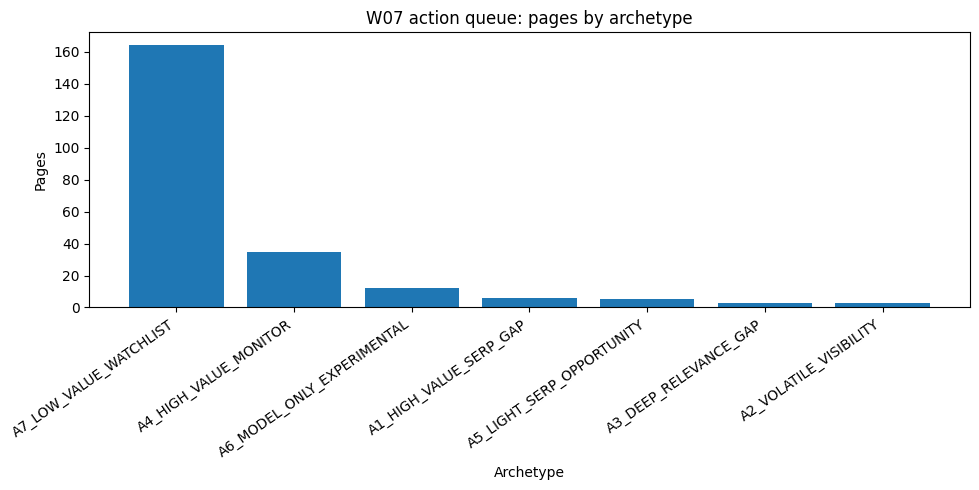

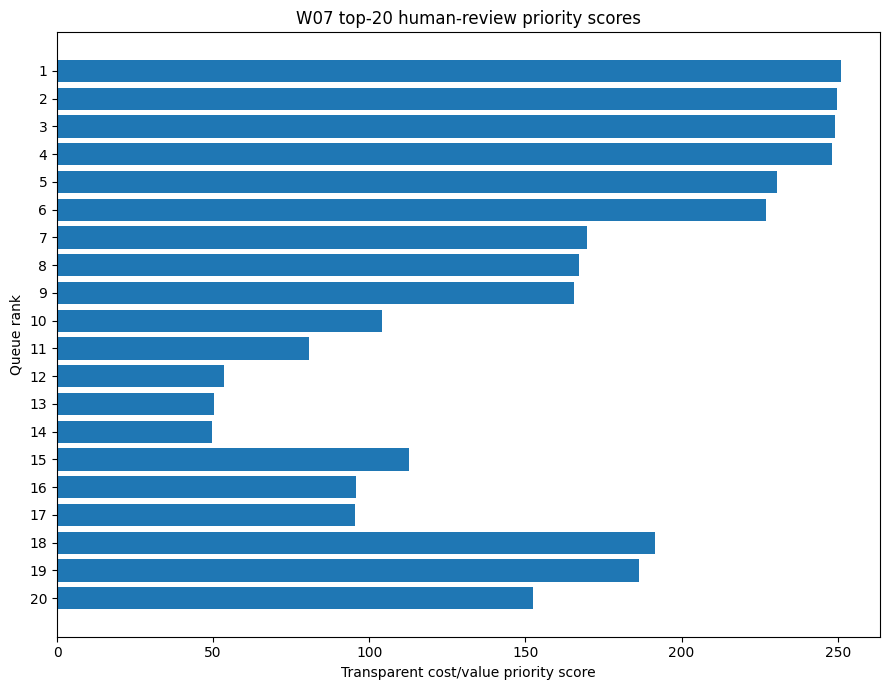

### Export policy check

,file,exists,git_ignored,expected_policy,policy_passed
0,work/outputs/w07_ranked_action_queue.csv,True,True,Ignored; notebook regenerates it,True
1,work/outputs/w07_action_playbook_metrics.json,True,False,Commit as a metrics receipt,True
2,work/figures/w07_action_mix.png,True,False,Commit for paper reuse,True
3,work/figures/w07_top20_priority_scores.png,True,False,Commit for paper reuse,True


### Queue export preview

,queue_rank,client_hash_id,content_hash_id,archetype,disposition,reviewer_role,recommended_action,reason_codes,value_tier,business_value_score,actionability_score,priority_score,estimated_review_hours,refresh_gate,decay_refresh_note,human_review_required,automation_allowed,rank_basis,model_signal_use,model_score_audit_only,model_rank_audit_only,hist_imp_per_day,hist_click_per_day,hist_ctr,hist_avg_position,hist_position_sd,human_decision,reviewer_role_or_name,review_date,review_notes,approved_action,action_owner,planned_measurement_start,planned_measurement_end
0,1,client_fef1a8f436438636,content_811c0e6db6e2cb7b,A1_HIGH_VALUE_SERP_GAP,REVIEW,SEO analyst + content editor,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,HIGH,98.245614,9,250.994152,0.75,HUMAN_STALENESS_CHECK_REQUIRED,"Check page age, last meaningful update, intent drift and competing results before deciding whether a refresh is justified.",True,False,Transparent value + actionability + estimated review cost; model score excluded,AUDIT_ONLY,0.332821,67,1585.375000,3.812500,0.002405,4.628794,0.446965,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,client_fef1a8f436438636,content_69560b448e635cdc,A1_HIGH_VALUE_SERP_GAP,REVIEW,SEO analyst + content editor,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,HIGH,97.368421,9,249.824561,0.75,HUMAN_STALENESS_CHECK_REQUIRED,"Check page age, last meaningful update, intent drift and competing results before deciding whether a refresh is justified.",True,False,Transparent value + actionability + estimated review cost; model score excluded,AUDIT_ONLY,0.345300,57,1499.687500,4.000000,0.002667,5.734445,0.599802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,client_fef1a8f436438636,content_0c681b2238bd38b7,A1_HIGH_VALUE_SERP_GAP,REVIEW,SEO analyst + content editor,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,HIGH,96.929825,9,249.239766,0.75,HUMAN_STALENESS_CHECK_REQUIRED,"Check page age, last meaningful update, intent drift and competing results before deciding whether a refresh is justified.",True,False,Transparent value + actionability + estimated review cost; model score excluded,AUDIT_ONLY,0.448114,23,1490.750000,3.375000,0.002264,11.053161,1.303395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,client_fef1a8f436438636,content_65cd4058b82bdfee,A1_HIGH_VALUE_SERP_GAP,REVIEW,SEO analyst + content editor,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R06_EXPERIMENTAL_MODEL_TOP20;R07_REFRESH_METADATA_REQUIRED,HIGH,96.052632,9,248.070175,0.75,HUMAN_STALENESS_CHECK_REQUIRED,"Check page age, last meaningful update, intent drift and competing results before deciding whether a refresh is justified.",True,False,Transparent value + actionability + estimated review cost; model score excluded,AUDIT_ONLY,0.481218,20,1398.375000,3.812500,0.002726,14.206266,2.902405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,client_fef1a8f436438636,content_58e36f43789b26ff,A1_HIGH_VALUE_SERP_GAP,REVIEW,SEO analyst + content editor,"Review search intent, title, meta description and SERP promise. Preserve strong sections; make only human-approved edits.",R01_HIGH_DEMAND;R02_LOW_CTR;R03_POSITION_4_TO_20;R07_REFRESH_METADATA_REQUIRED,HIGH,82.894737,9,230.526316,0.75,HUMAN_STALENESS_CHECK_REQUIRED,"Check page age, last meaningful update, intent drift and competing results before deciding whether a refresh is justified.",True,False,Transparent value + actionability + estimated review cost; model score excluded,AUDIT_ONLY,0.3

### Metrics receipt

,queue_csv,metrics_json,figures,queue_rows,production_gate,automation_allowed
0,work/outputs/w07_ranked_action_queue.csv,work/outputs/w07_action_playbook_metrics.json,"work/figures/w07_action_mix.png, work/figures/w07_top20_priority_scores.png",228,BLOCKED,False


PASS: ranked queue exported.
PASS: metrics JSON created and is commit-eligible.
PASS: paper figures created under work/figures/.
PASS: queue CSV is ignored by git and will be regenerated.
PASS: no automation is permitted.


In [5]:
# Exports for the research paper

QUEUE_PATH = OUTPUT_DIR / "w07_ranked_action_queue.csv"
METRICS_PATH = OUTPUT_DIR / "w07_action_playbook_metrics.json"
ACTION_MIX_FIGURE = FIGURE_DIR / "w07_action_mix.png"
TOP20_FIGURE = FIGURE_DIR / "w07_top20_priority_scores.png"

export_columns = [
    "queue_rank",
    GROUP,
    CONTENT_ID,
    "archetype",
    "disposition",
    "reviewer_role",
    "recommended_action",
    "reason_codes",
    "value_tier",
    "business_value_score",
    "actionability_score",
    "priority_score",
    "estimated_review_hours",
    "refresh_gate",
    "decay_refresh_note",
    "human_review_required",
    "automation_allowed",
    "rank_basis",
    "model_signal_use",
    "model_score_audit_only",
    "model_rank_audit_only",
    "hist_imp_per_day",
    "hist_click_per_day",
    "hist_ctr",
    "hist_avg_position",
    "hist_position_sd",
    "human_decision",
    "reviewer_role_or_name",
    "review_date",
    "review_notes",
    "approved_action",
    "action_owner",
    "planned_measurement_start",
    "planned_measurement_end",
]

action_queue[export_columns].to_csv(
    QUEUE_PATH,
    index=False,
)

action_mix = (
    action_queue["archetype"]
    .value_counts()
    .rename_axis("archetype")
    .reset_index(name="pages")
)

# Figure 1: queue composition
plt.figure(figsize=(10, 5))
plt.bar(
    action_mix["archetype"],
    action_mix["pages"],
)
plt.title("W07 action queue: pages by archetype")
plt.xlabel("Archetype")
plt.ylabel("Pages")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(
    ACTION_MIX_FIGURE,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close()

# Figure 2: top-20 cost/value priorities
top20_plot = (
    action_queue
    .head(20)
    .sort_values("queue_rank", ascending=False)
)

plt.figure(figsize=(9, 7))
plt.barh(
    top20_plot["queue_rank"].astype(str),
    top20_plot["priority_score"],
)
plt.title("W07 top-20 human-review priority scores")
plt.xlabel("Transparent cost/value priority score")
plt.ylabel("Queue rank")
plt.tight_layout()
plt.savefig(
    TOP20_FIGURE,
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close()

metrics_receipt = {
    "assignment": "ML-10 Content Action Playbook",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "repository": "Cyb3rVigil/flyrank-ml-internship",
    "data_scope": {
        "warehouse_build_reference": "v20260703",
        "source_month": "2026-03",
        "feature_window": "2026-03-01 through 2026-03-21",
        "outcome_window": "2026-03-22 through 2026-03-31",
        "eligibility": {
            "minimum_history_days": 14,
            "minimum_outcome_days": 7,
            "minimum_history_impressions": 50,
            "ga4_data_available": True,
        },
        "eligible_rows": int(len(model_frame)),
        "eligible_clients": int(model_frame[GROUP].nunique()),
    },
    "split": {
        "method": "GroupShuffleSplit",
        "group": GROUP,
        "test_size": 0.25,
        "random_seed": SEED,
        "train_rows": int(len(train_frame)),
        "train_clients": int(train_frame[GROUP].nunique()),
        "test_rows": int(len(test_frame)),
        "test_clients": int(test_frame[GROUP].nunique()),
        "client_overlap": int(
            len(train_clients.intersection(test_clients))
        ),
    },
    "features": FEATURES,
    "label": {
        "name": LABEL,
        "definition": (
            "Outcome impressions/day < 0.8 * historical "
            "impressions/day"
        ),
        "claim_level": "Short-window decline proxy; not causal",
    },
    "validation": {
        "model": "Logistic Regression",
        "test_base_rate": test_base_rate,
        "precision_at_20": model_p20,
        "precision_at_50": model_p50,
        "average_precision": model_average_precision,
        "roc_auc": model_roc_auc,
        "baseline_precision_at_20": baseline_p20,
        "production_gate": "BLOCKED",
        "model_score_use": "AUDIT_ONLY",
    },
    "training_only_thresholds": baseline_thresholds,
    "queue": {
        "rows": int(len(action_queue)),
        "top_k_displayed": 20,
        "rank_basis": (
            "Transparent business value + actionability + estimated "
            "review cost; model score excluded"
        ),
        "human_review_required": True,
        "automation_allowed": False,
        "archetype_counts": {
            str(key): int(value)
            for key, value in (
                action_queue["archetype"]
                .value_counts()
                .to_dict()
                .items()
            )
        },
        "disposition_counts": {
            str(key): int(value)
            for key, value in (
                action_queue["disposition"]
                .value_counts()
                .to_dict()
                .items()
            )
        },
    },
    "monitoring": {
        "psi_review_threshold": 0.20,
        "psi_watch_threshold": 0.10,
        "base_rate_absolute_change_trigger": 0.05,
        "row_or_client_count_change_trigger": 0.30,
        "missingness_change_trigger_pp": 10.0,
        "human_acceptance_rate_trigger": 0.30,
        "current_feature_psi": {
            row["feature"]: (
                None
                if pd.isna(row["psi"])
                else float(row["psi"])
            )
            for _, row in drift_table.iterrows()
        },
    },
    "limits": [
        "One March 2026 window",
        "Small held-out client set",
        "Proxy label",
        "GA4 availability and exposure filters",
        "No page-age or refresh-history features",
        "No causal intervention design",
        "Not validated for automated or production decisions",
    ],
    "export_files": {
        "ranked_queue_csv": str(
            QUEUE_PATH.relative_to(REPO_ROOT)
        ),
        "metrics_json": str(
            METRICS_PATH.relative_to(REPO_ROOT)
        ),
        "action_mix_figure": str(
            ACTION_MIX_FIGURE.relative_to(REPO_ROOT)
        ),
        "top20_figure": str(
            TOP20_FIGURE.relative_to(REPO_ROOT)
        ),
    },
}

with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(
        metrics_receipt,
        file,
        indent=2,
        ensure_ascii=False,
    )

# ---------------------------------------------------------
# Privacy and export checks
# ---------------------------------------------------------

assert QUEUE_PATH.exists()
assert METRICS_PATH.exists()
assert ACTION_MIX_FIGURE.exists()
assert TOP20_FIGURE.exists()

assert len(action_queue) == len(test_frame)
assert action_queue["queue_rank"].tolist() == list(
    range(1, len(action_queue) + 1)
)
assert action_queue["automation_allowed"].eq(False).all()
assert action_queue["human_review_required"].eq(True).all()
assert action_queue["reason_codes"].str.len().gt(0).all()

blocked_export_columns = {
    "client_name",
    "url",
    "domain",
    "title",
    "keyword",
    "query",
    "private_query",
}

assert blocked_export_columns.isdisjoint(
    set(export_columns)
)

string_export = (
    action_queue[export_columns]
    .select_dtypes(include=["object", "string"])
    .fillna("")
    .astype(str)
)

contains_url = (
    string_export
    .apply(
        lambda column: column.str.contains(
            r"https?://|www\.",
            case=False,
            regex=True,
        )
    )
    .any()
    .any()
)

assert not contains_url

def is_git_ignored(path):
    result = subprocess.run(
        [
            "git",
            "check-ignore",
            "-q",
            str(path.relative_to(REPO_ROOT)),
        ],
        cwd=REPO_ROOT,
        check=False,
    )
    return result.returncode == 0

queue_is_ignored = is_git_ignored(QUEUE_PATH)
metrics_is_ignored = is_git_ignored(METRICS_PATH)
action_figure_is_ignored = is_git_ignored(ACTION_MIX_FIGURE)
top20_figure_is_ignored = is_git_ignored(TOP20_FIGURE)

git_policy_check = pd.DataFrame([
    {
        "file": str(QUEUE_PATH.relative_to(REPO_ROOT)),
        "exists": QUEUE_PATH.exists(),
        "git_ignored": queue_is_ignored,
        "expected_policy": "Ignored; notebook regenerates it",
        "policy_passed": queue_is_ignored,
    },
    {
        "file": str(METRICS_PATH.relative_to(REPO_ROOT)),
        "exists": METRICS_PATH.exists(),
        "git_ignored": metrics_is_ignored,
        "expected_policy": "Commit as a metrics receipt",
        "policy_passed": not metrics_is_ignored,
    },
    {
        "file": str(ACTION_MIX_FIGURE.relative_to(REPO_ROOT)),
        "exists": ACTION_MIX_FIGURE.exists(),
        "git_ignored": action_figure_is_ignored,
        "expected_policy": "Commit for paper reuse",
        "policy_passed": not action_figure_is_ignored,
    },
    {
        "file": str(TOP20_FIGURE.relative_to(REPO_ROOT)),
        "exists": TOP20_FIGURE.exists(),
        "git_ignored": top20_figure_is_ignored,
        "expected_policy": "Commit for paper reuse",
        "policy_passed": not top20_figure_is_ignored,
    },
])

display(Markdown("### Export policy check"))
display(git_policy_check)

display(Markdown("### Queue export preview"))
display(
    pd.read_csv(QUEUE_PATH)
    .head(10)
)

display(Markdown("### Metrics receipt"))
display(
    pd.DataFrame([{
        "queue_csv": str(
            QUEUE_PATH.relative_to(REPO_ROOT)
        ),
        "metrics_json": str(
            METRICS_PATH.relative_to(REPO_ROOT)
        ),
        "figures": (
            f"{ACTION_MIX_FIGURE.relative_to(REPO_ROOT)}, "
            f"{TOP20_FIGURE.relative_to(REPO_ROOT)}"
        ),
        "queue_rows": len(action_queue),
        "production_gate": "BLOCKED",
        "automation_allowed": False,
    }])
)

assert git_policy_check["policy_passed"].all()

print("PASS: ranked queue exported.")
print("PASS: metrics JSON created and is commit-eligible.")
print("PASS: paper figures created under work/figures/.")
print("PASS: queue CSV is ignored by git and will be regenerated.")
print("PASS: no automation is permitted.")

## Self-check

Mark each item only after running **Runtime → Run all** successfully:

- [x] Every section contains both written reasoning and supporting code.
- [x] The notebook runs top to bottom without an error.
- [x] The validation table reports zero client overlap.
- [x] The model score is marked audit-only.
- [x] The operational rank excludes the weak model score.
- [x] Every queue row requires human review.
- [x] Every queue row has `automation_allowed = False`.
- [x] The no-go list clearly states what must not be automated.
- [x] `work/outputs/w07_ranked_action_queue.csv` is generated and git-ignored.
- [x] `work/outputs/w07_action_playbook_metrics.json` is generated and committed.
- [x] Reusable figures are generated under `work/figures/` and committed.
- [x] No client names, domains, URLs, titles, keywords or private queries appear.
- [x] Claims use observed, measured, directional and decision-support language.
- [x] The executed notebook is saved as `work/notebooks/w07_action_playbook.ipynb`.
- [x] The submitted link is the repository URL, not a Colab or Drive URL.